In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

### The Exponential Distribution

#### Memoryless property

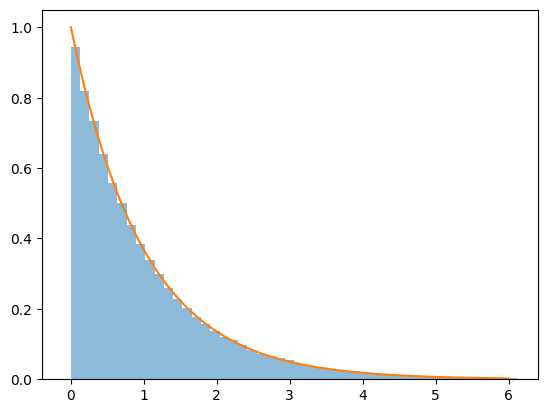

In [22]:
n = 1_000_000
x = stats.expon().rvs(size=n)
plt.hist(x[x > 2] - 2, density=True, bins=100, alpha=0.5)
grid = np.linspace(0, 6, 1000)
plt.plot(grid, stats.expon().pdf(grid))
plt.xlim(-0.4, 6.4)
plt.show()

$\operatorname{Exp}(2)=\chi^2_2$

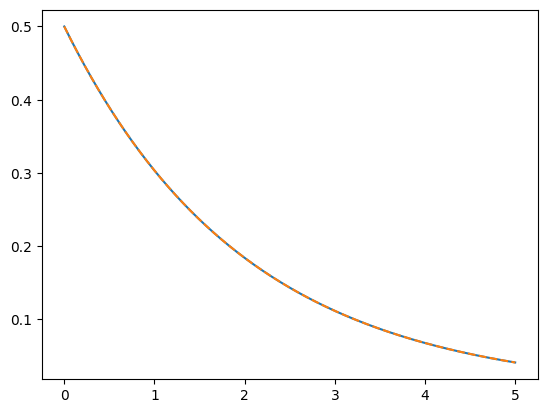

In [12]:
grid = np.linspace(0, 5, 1000)
plt.plot(grid, stats.expon(scale=2).pdf(grid))
plt.plot(grid, stats.chi2(df=2).pdf(grid), "--")

PPF-transform

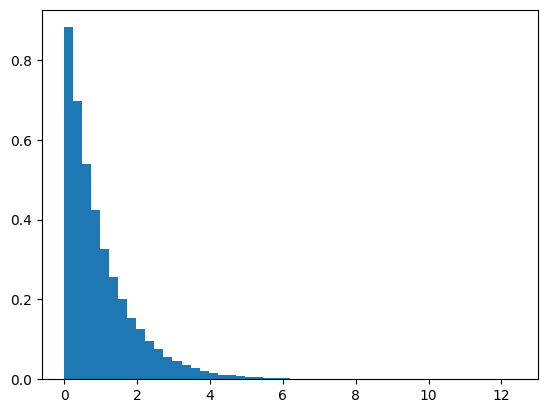

In [22]:
n = 100_000
x = stats.uniform().rvs(size=n)
plt.hist(stats.expon().ppf(x), bins=50, density=True)
plt.show()

If $U\sim\operatorname{Uniform}(0, 1)$, then $-\log U\sim \operatorname{Exp}(1)$.

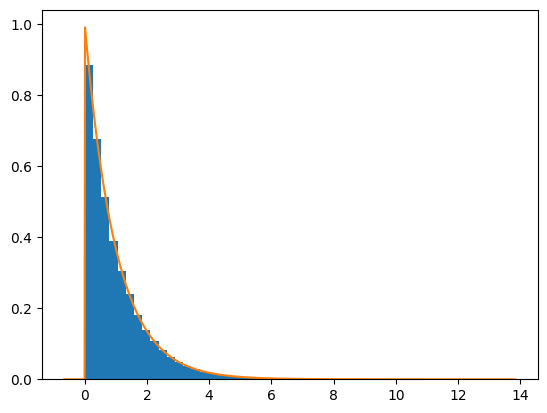

In [20]:
n = 100_000
x = stats.uniform().rvs(size=n)
plt.hist(-np.log(x), bins=50, density=True)
grid = np.linspace(*plt.xlim(), 1000)
plt.plot(grid, stats.expon().pdf(grid))
plt.show()

### The Poisson and Exponential Distributions

In [36]:
def sim_poisson(n, scale=1.0, rng=None):
    rng = np.random.default_rng(rng)
    xs = np.zeros(n)
    for i in range(n):
        t = 0
        x = 0
        while True:
            t += rng.exponential(scale)
            if t < 1:
                x += 1
            else:
                break
        xs[i] = x
    return xs

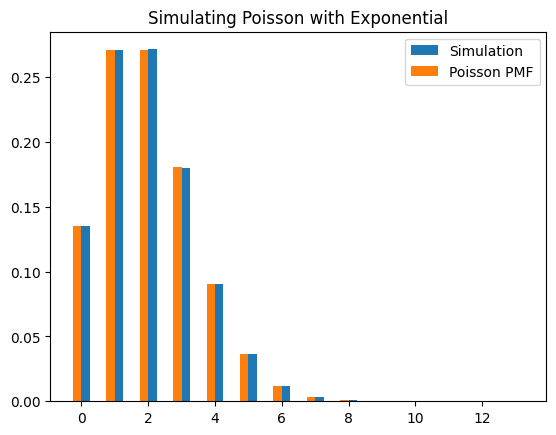

In [37]:
n = 1_000_000
scale = 0.5
xs = sim_poisson(n, scale=scale)
items, counts = np.unique_counts(xs)
plt.bar(items, counts / n, align="edge", width=0.25, label="Simulation")
plt.bar(
    items,
    stats.poisson.pmf(items, mu=1 / scale),
    align="edge",
    width=-0.25,
    label="Poisson PMF",
)
plt.legend()
plt.title("Simulating Poisson with Exponential")
plt.show()

##### $x\sim\operatorname{Poisson}(a),\, y\sim\operatorname{Poisson}(b) \Longrightarrow x + y \sim\operatorname{Poisson}(a + b)$

Let `x` and `y` be vectors of `1_000_000` samples drawn independently from Poisson distributions with rate parameters `2` and `5`, respectively. Using a bar chart, that the `x + y` is has an approximately Poisson distribution with rate parameter `2 + 5`.

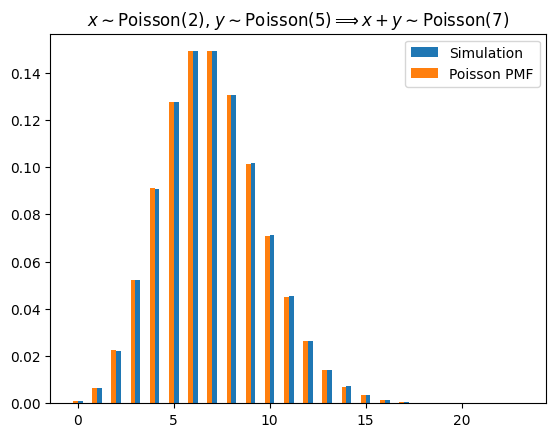

In [ ]:
n = 1_000_000
x = stats.poisson(2).rvs(n)
y = stats.poisson(5).rvs(n)
z = x + y
items, counts = np.unique_counts(z)
plt.bar(items, counts / n, align="edge", width=0.25, label="Simulation")
plt.bar(
    items,
    stats.poisson.pmf(items, mu=7),
    align="edge",
    width=-0.25,
    label="Poisson PMF",
)
plt.legend()
plt.title(
    "$x\\sim\\operatorname{Poisson}(2)$, $y\\sim\\operatorname{Poisson}(5)\\Longrightarrow x + y\\sim\\operatorname{Poisson}(7)$"
)
plt.show()

##### Exercise

Prove that if $x\sim\operatorname{Poisson}(a)$ and $x\sim\operatorname{Poisson}(b)$ then
$x + y\sim\operatorname{Poisson}(a + b)$. Proceed as follows:

1. Explain why the identity
   $$
     P(x + y = n) = \sum_{k=0}^n P(x=k)P(y=n - k)
   $$
   holds.

2. Using the formulas
   $$
     P(x=k) = \frac{e^{-a}a^k}{k!}\qquad\text{and}\qquad
     P(y=\ell) = \frac{e^{-b}b^\ell}{\ell!},
   $$
   show that
   $$
   P(x + y = n) = \frac{e^{-(a + b)}}{n!}\sum_{k=0}^n\frac{n!}{k!(n - k)!}a^k b^{n - k}
   $$

3. Deduce, from the binomial expansion formula, that
   $$
   P(x + y = n) = \frac{e^{-(a + b)}(a+b)^n}{n!}
   $$

##### Solution
$$
\begin{aligned}
P(x + y = n) &= \sum_{k=0}^n P(x=k)P(y=n - k)\\
&= \sum_{k=0}^n\frac{e^{-a}a^k}{k!}\frac{e^{-b}b^{n - k}}{(n - k)!}\\
&= e^{-(a + b)}\sum_{k=0}^n\frac1{k!(n - k)!}a^k b^{n - k}\\
&= \frac{e^{-(a + b)}}{n!}\sum_{k=0}^n\frac{n!}{k!(n - k)!}a^k b^{n - k}\\
&= \frac{e^{-(a + b)}}{n!}\sum_{k=0}^n\binom{n}{k}a^k b^{n - k}\\
&= \frac{e^{-(a + b)}(a+b)^n}{n!}
\end{aligned}
$$

##### Exercise

Suppose
$$
x\sim \operatorname{Poisson}(a)\qquad\text{and}\qquad
y\sim \operatorname{Poisson}(b).
$$
Prove that
$$
x\mid x+y=n\sim \operatorname{Bin}\left(n, \theta\right),
$$
where
$$
\theta = \frac{a}{a + b}.
$$

Hint: Use the previous exercise to show that
$$
P(x = k\mid x + y = n)
= \binom{n}{k}\theta^k\left(1 - \theta\right)^{n - k}.
$$

##### Solution

$$
\begin{aligned}
P(x = k\mid x + y = n) &= \frac{P(x = k)P(y = n - k)}{P(x + y = n)}\\
&= \frac{\quad\dfrac{e^{-a}a^k}{k!}\dfrac{e^{-b}b^{n - k}}{(n - k)!}\quad}{\dfrac{e^{-(a + b)}(a + b)^n}{n!}}\\
&= \binom{n}{k}\left(\frac{a}{a + b}\right)^k\left(\frac{b}{a + b}\right)^{n - k}\\
&= \binom{n}{k}\theta^k\left(1 - \theta\right)^{n - k}
\end{aligned} 
$$

Verify the above exercise by simulation:

Let `x` and `y` be vectors of `1_000_000` samples drawn independently from Poisson distributions with rate parameters `2` and `5`, respectively. Using bar charts, plot the distribution of the `x[I]`, where `I` is the mask defined by `x + y == 7`, together with the probability mass function of $\operatorname{Bin}(7, 2/7)$.

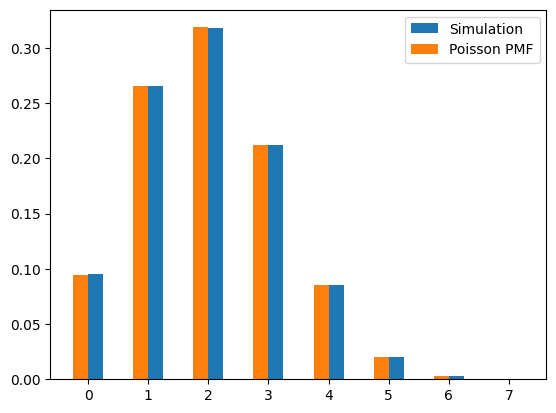

In [ ]:
n = 1_000_000
a = 2
b = 5
x = stats.poisson(a).rvs(size=n)
y = stats.poisson(b).rvs(size=n)
I = x + y == a + b
items, counts = np.unique_counts(x[I])
plt.bar(items, counts / len(x[I]), align="edge", width=0.25, label="Simulation")
plt.bar(
    items,
    stats.binom.pmf(items, n=7, p=2 / 7),
    align="edge",
    width=-0.25,
    label="Poisson PMF",
)
plt.legend()
plt.show()

##### Exercise

If $p$ is small, then $\operatorname{Poisson}(np)$ is a good approximation to $\operatorname{Bin}(n, p)$.
Produce a visualization of this principle by plotting the probability mass functions of $\operatorname{Bin}(100, 0.05)$ and of $\operatorname{Poisson}(100\cdot 0.05)$ on the same axes.

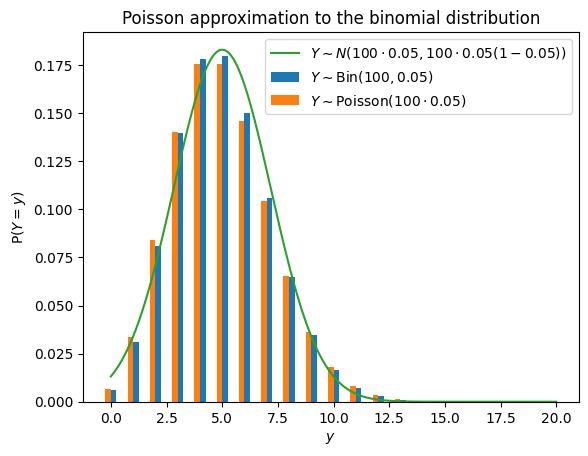

In [25]:
n = 100
p = 0.05
y = np.arange(20)
plt.bar(
    y,
    stats.binom.pmf(y, n=n, p=p),
    align="edge",
    width=0.25,
    label=f"$Y\\sim \\operatorname{{Bin}}({n}, {p})$",
)
plt.bar(
    y,
    stats.poisson.pmf(y, mu=n * p),
    align="edge",
    width=-0.25,
    label=f"$Y\\sim \\operatorname{{Poisson}}({n}\\cdot {p})$",
)
grid = np.linspace(0, 20, 1000)
plt.plot(
    grid,
    stats.norm.pdf(grid, loc=n * p, scale=np.sqrt(n * p * (1 - p))),
    "C2",
    label=f"$Y\\sim N({n}\\cdot {p}, {n}\\cdot{p}(1 - {p}))$",
)
plt.xlabel("$y$")
plt.ylabel("$\\operatorname{P}(Y=y)$")
plt.title("Poisson approximation to the binomial distribution")
plt.legend()
plt.show()

Suppose $x_n\to x$ as $n\to\infty$. Then
$$
\left(1 + \frac{x_n}{n}\right)^n \to e^x\quad\text{as}\quad n\to\infty.
$$

Set $\lambda_n=np_n$ and suppose
$$
\lim_{n\to\infty}\lambda_n = \lambda > 0.
$$

We have:
$$
\begin{aligned}
\binom{n}kp_n^k(1 - p_n)^{n - k} &=\frac1{k!} \frac{n!}{(n - k)!n^k}(np_n)^k\left(1 - \frac{np_n}{n}\right)^{n}\left(1 - \frac{np_n}{n}\right)^{- k}\\
&= \frac1{k!} \frac{n!}{(n - k)!n^k} \lambda_n^k \left(1 - \frac{\lambda_n}{n}\right)^n
\left(1 - \frac{\lambda_n}{n}\right)^{-k}
\end{aligned}
$$

Observe:
$$
\begin{aligned}
&\lim_{n\to\infty}\frac{n!}{(n - k)!n^k} = \lim_{n\to\infty}\prod_{j=0}^{k-1}\frac{n - j}{n} = 1,\\
&\lim_{n\to\infty}\lambda_n^k = \lambda^k,\\
&\lim_{n\to\infty}\left(1 - \frac{\lambda_n}{n}\right)^{n} = e^{-\lambda},\\
&\lim_{n\to\infty}\left(1 - \frac{\lambda_n}{n}\right)^{-k} = 1
\end{aligned}
$$

Substituting, we conclude:
$$
\lim_{n\to\infty} \binom{n}kp_n^k(1 - p_n)^{n - k}
=\frac{1}{k!}\lambda^ke^{-\lambda}
$$